## Análisis de Correlación: IPC vs Actividad Empresarial

### Objetivo
Analizar la **correlación estadística** entre el IPC nacional (índice general) y la actividad empresarial (sociedades constituidas y disueltas) a nivel nacional en España, cubriendo el periodo **enero 2008 – mayo 2026**.

### Metodología
1. **Preparación de datos**: Agregación de empresas a nivel nacional y unión con el IPC.
2. **Correlación directa**: Comparación de coeficientes de Pearson y Spearman.
3. **Matriz de correlación**: Visualización heatmap de las tres variables.
4. **Análisis de lag**: Evaluación de correlaciones con desfases de 1-3 meses.
5. **Visualización**: Scatter plots con línea de tendencia.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from correlation.correlation import comparar_correlaciones, matriz_correlacion_visual

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

### 1. Preparación de datos

In [2]:
df_ipc = pd.read_csv('../files/data_processed/ipc.csv')
df_const = pd.read_csv('../files/data_processed/empresas_constituidas.csv')
df_dis = pd.read_csv('../files/data_processed/empresas_disueltas.csv')

# Filtros: id_territorio=1 (nacional), id_sector=1 (Índice General),
# id_medida=1 (índice, no variación ni ponderación)
ipc_nacional = df_ipc[
    (df_ipc['id_territorio'] == 1) &    
    (df_ipc['id_sector'] == 1) &        
    (df_ipc['id_medida'] == 1)           
][['id_tiempo', 'valor_ipc']]

# 2. Constituidas nacionales: sumar todas las CCAA por periodo
const_nacional = (
    df_const
    .groupby('id_tiempo')['numero_sociedades']
    .sum()
    .reset_index()
    .rename(columns={'numero_sociedades': 'constituidas'})
)

# 3. Disueltas nacionales: sumar todas las CCAA por periodo
dis_nacional = (
    df_dis
    .groupby('id_tiempo')['numero_sociedades']
    .sum()
    .reset_index()
    .rename(columns={'numero_sociedades': 'disueltas'})
)

# 4. Merge de las tres fuentes
df_corr = (
    ipc_nacional
    .merge(const_nacional, on='id_tiempo', how='inner')
    .merge(dis_nacional, on='id_tiempo', how='inner')
    .sort_values('id_tiempo')
    .reset_index(drop=True)
)

print(f'Registros totales IPC:       {len(ipc_nacional)}')
print(f'Registros totales const.:    {len(const_nacional)}')
print(f'Registros totales dis.:      {len(dis_nacional)}')
print(f'Registros tras merge:        {len(df_corr)}')
print(f'Periodo: {df_corr["id_tiempo"].min()} – {df_corr["id_tiempo"].max()}')
df_corr.head(10)

Registros totales IPC:       293
Registros totales const.:    220
Registros totales dis.:      220
Registros tras merge:        220
Periodo: 200801 – 202604


,id_tiempo,valor_ipc,constituidas,disueltas
0,200801,71.442,11764,2495
1,200802,71.553,11930,1929
2,200803,72.188,9757,1066
3,200804,72.965,11118,1193
4,200805,73.458,9487,1088
5,200806,73.881,8250,835
6,200807,73.526,8104,1061
7,200808,73.368,5806,741
8,200809,73.353,7337,1198
9,200810,73.605,6902,1266


### 2. Resumen descriptivo

In [3]:
df_corr[['valor_ipc', 'constituidas', 'disueltas']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
valor_ipc,220.0,82.85,8.33,71.44,77.86,79.91,85.32,102.88
constituidas,220.0,8109.33,1772.33,2314.00,6850.50,8023.50,9029.25,14307.00
disueltas,220.0,1853.25,691.21,404.00,1368.50,1664.00,2201.75,4157.00


### 3. Correlación directa: IPC vs Constituidas

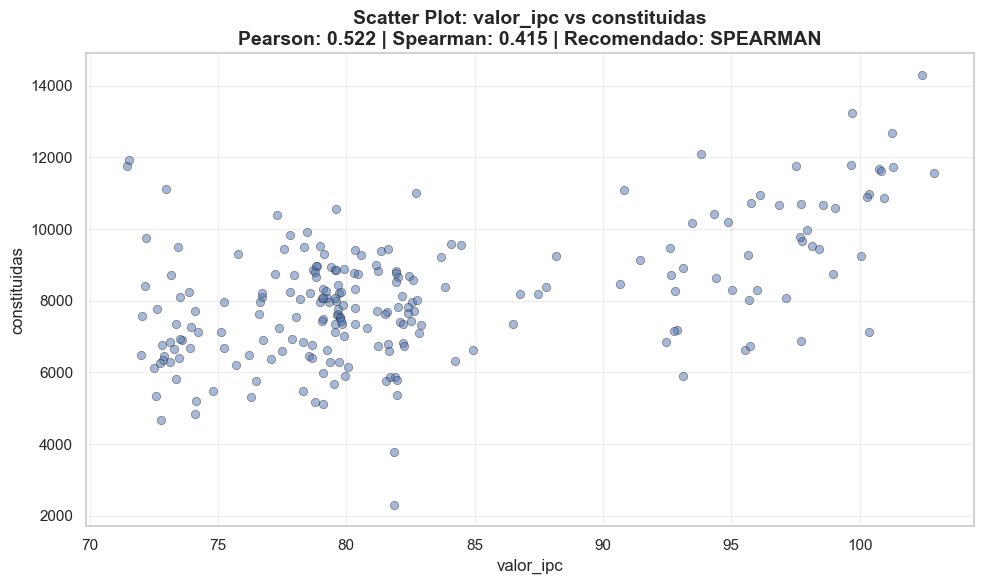


⚠️  USAR SPEARMAN (r = 0.415)
   
   Razón: Hay una diferencia notable entre Pearson y Spearman (0.107).
   Esto sugiere presencia de outliers o relación no lineal.
   Spearman es más robusto en estos casos.
   
   Pearson: 0.522
   Spearman: 0.415
   
   Datos utilizados: 220/220 (100.0%)
        
   Fuerza de la relación: moderada positiva


In [4]:
result_const = comparar_correlaciones(df_corr, 'valor_ipc', 'constituidas')
print(result_const['interpretacion'])

### 4. Correlación directa: IPC vs Disueltas

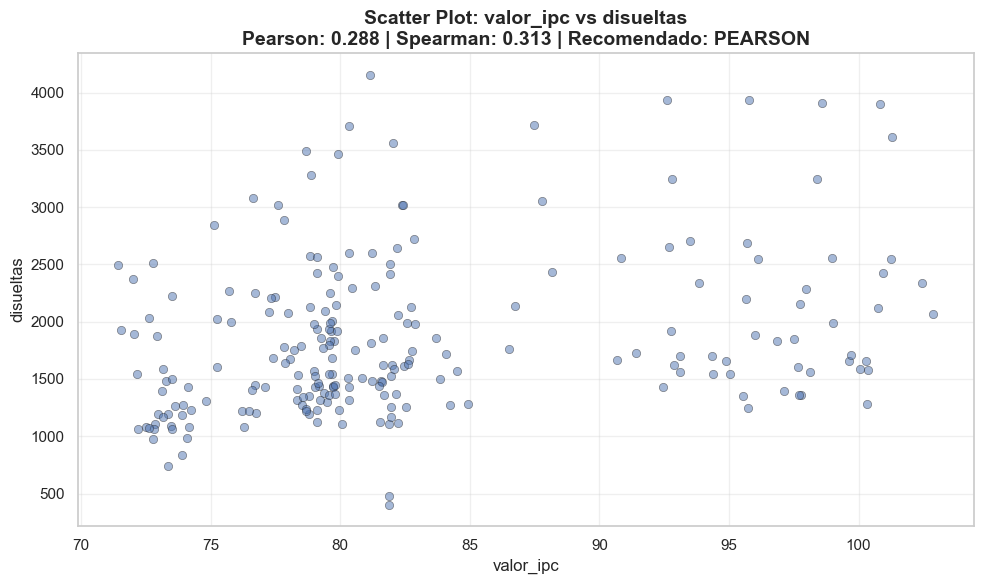


✅ USAR PEARSON (r = 0.288)
   
   Razón: La diferencia entre Pearson y Spearman es pequeña (0.025).
   Esto indica una relación aproximadamente lineal sin outliers significativos.
   
   Pearson: 0.288
   Spearman: 0.313
   
   Datos utilizados: 220/220 (100.0%)
        
   Fuerza de la relación: débil positiva


In [5]:
result_dis = comparar_correlaciones(df_corr, 'valor_ipc', 'disueltas')
print(result_dis['interpretacion'])

### 5. Matriz de correlación (heatmap)

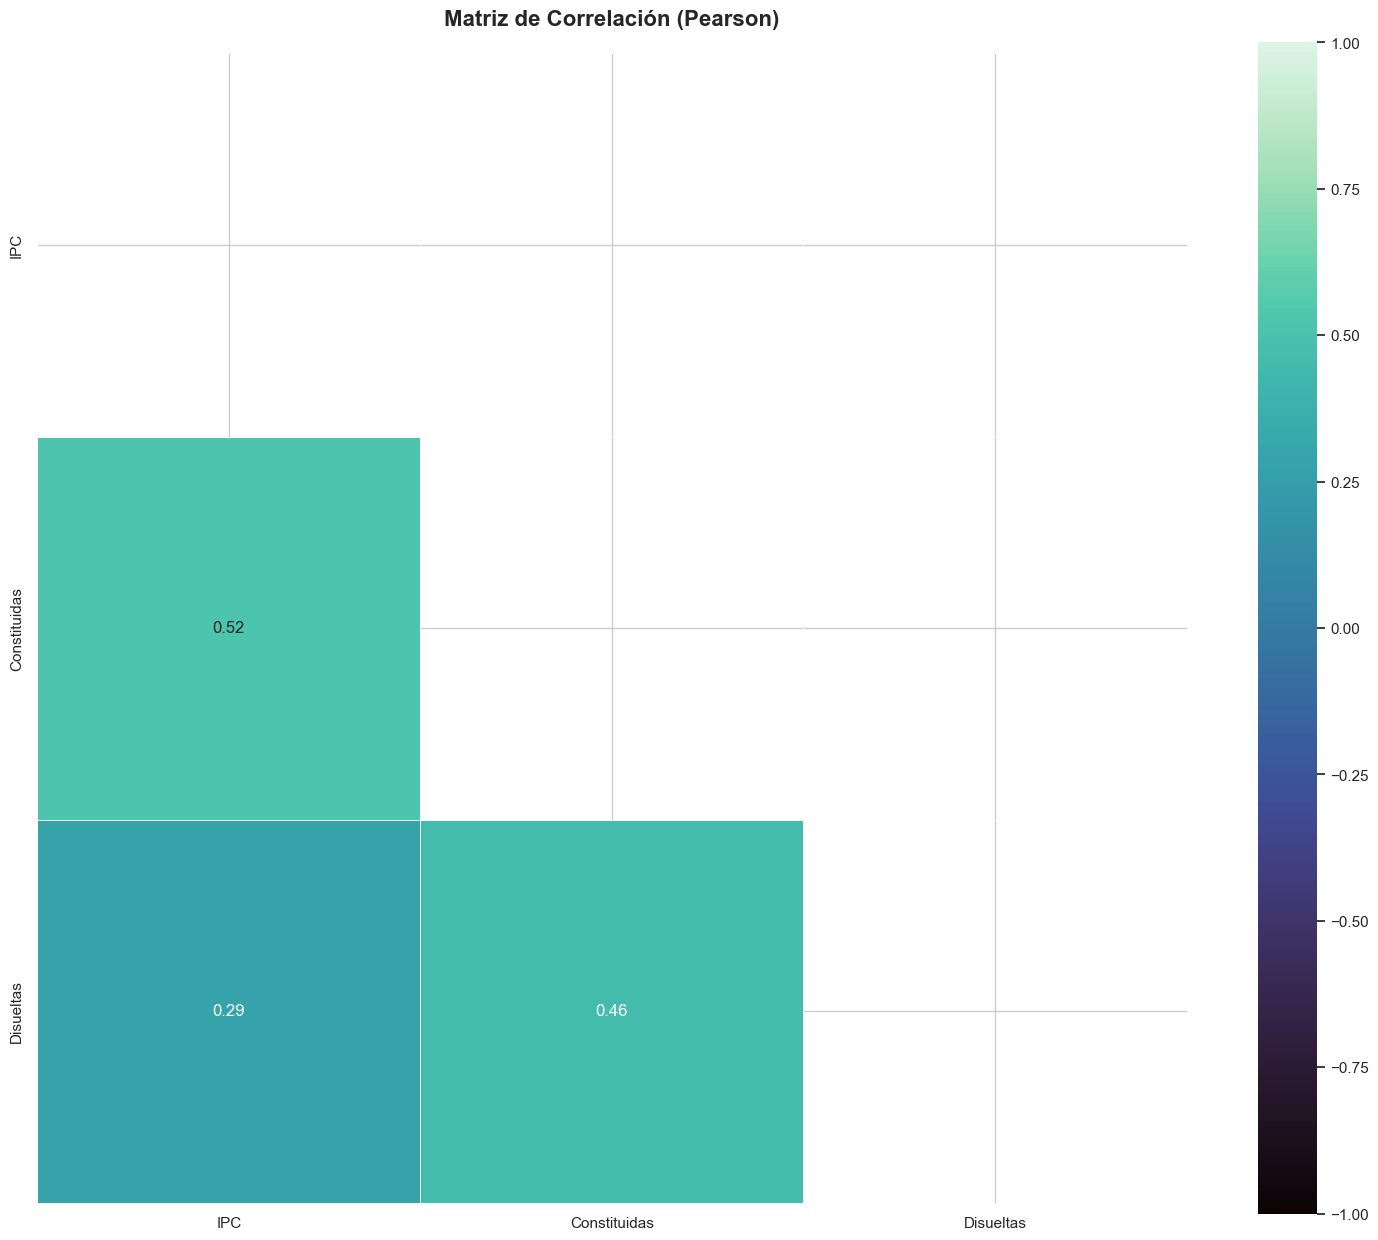

,IPC,Constituidas,Disueltas
IPC,1.000000,0.521535,0.287747
Constituidas,0.521535,1.000000,0.458652
Disueltas,0.287747,0.458652,1.000000


In [6]:
df_heatmap = df_corr[['valor_ipc', 'constituidas', 'disueltas']].copy()
df_heatmap.columns = ['IPC', 'Constituidas', 'Disueltas']

matriz_correlacion_visual(df_heatmap, metodo='pearson', cmap='mako')

### 6. Análisis de Lag (1-3 meses)

Evalúa si el IPC **anticipa** o **retrasa** la actividad empresarial, desplazando las series de empresas 1, 2 y 3 meses hacia el futuro/pasado.

In [7]:
lags = [1, 2, 3]
resultados_lag = []

for lag in lags:
    # IPC vs constituidas desplazada (constituidas de hace N meses vs IPC actual)
    col_const_lag = f'constituidas_lag{lag}'
    col_dis_lag = f'disueltas_lag{lag}'

    # Nota: shift() genera NaN en las primeras N filas (N=lag).
    df_corr[col_const_lag] = df_corr['constituidas'].shift(lag)     
    df_corr[col_dis_lag] = df_corr['disueltas'].shift(lag)

    # Pearson con valores válidos
    # dropna() las elimina, por lo que el tamaño muestral se reduce.
    pearson_const = df_corr[['valor_ipc', col_const_lag]].dropna().corr().iloc[0, 1]
    spearman_const = df_corr[['valor_ipc', col_const_lag]].dropna().corr(method='spearman').iloc[0, 1]
    pearson_dis = df_corr[['valor_ipc', col_dis_lag]].dropna().corr().iloc[0, 1]
    spearman_dis = df_corr[['valor_ipc', col_dis_lag]].dropna().corr(method='spearman').iloc[0, 1]

    resultados_lag.append({
        'Lag (meses)': lag,
        'IPC vs Constituidas (Pearson)': round(pearson_const, 4),
        'IPC vs Constituidas (Spearman)': round(spearman_const, 4),
        'IPC vs Disueltas (Pearson)': round(pearson_dis, 4),
        'IPC vs Disueltas (Spearman)': round(spearman_dis, 4)
    })

df_lags = pd.DataFrame(resultados_lag)
print('Interpretación: un lag positivo significa que el IPC actual se compara con la actividad empresarial de hace N meses.')
print('Si la correlación aumenta con el lag, el IPC podría "anticipar" la actividad empresarial.\n')
df_lags

Interpretación: un lag positivo significa que el IPC actual se compara con la actividad empresarial de hace N meses.
Si la correlación aumenta con el lag, el IPC podría "anticipar" la actividad empresarial.



,Lag (meses),IPC vs Constituidas (Pearson),IPC vs Constituidas (Spearman),IPC vs Disueltas (Pearson),IPC vs Disueltas (Spearman)
0,1,0.5209,0.4221,0.2823,0.2880
1,2,0.5027,0.4103,0.2885,0.2804
2,3,0.4935,0.4129,0.3022,0.2989


In [14]:
# Resumen: dirección de la mejor correlación por lag
print('=== Resumen de direcciones de lag ===')
print()

# Correlación directa (sin lag)
p0_const = df_corr[['valor_ipc', 'constituidas']].dropna().corr().iloc[0, 1]
p0_dis = df_corr[['valor_ipc', 'disueltas']].dropna().corr().iloc[0, 1]
print(f'IPC vs Constituidas (sin lag):  r = {p0_const:.4f}')
print(f'IPC vs Disueltas (sin lag):     r = {p0_dis:.4f}')
print()

for _, row in df_lags.iterrows():
    lag = int(row['Lag (meses)'])
    p_c = row['IPC vs Constituidas (Pearson)']
    p_d = row['IPC vs Disueltas (Pearson)']
    print(f'IPC vs Constituidas (lag {lag}m): r = {p_c:.4f}  |  IPC vs Disueltas (lag {lag}m): r = {p_d:.4f}')

    # Usar Spearman para constituidas (recomendado) y Pearson para disueltas
best_const_lag = df_lags.loc[
    df_lags['IPC vs Constituidas (Spearman)'].abs().idxmax()
]
best_dis_lag = df_lags.loc[
    df_lags['IPC vs Disueltas (Pearson)'].abs().idxmax()
]
print()
print('Si la correlación con lag es más fuerte que sin lag, indica que el IPC se relaciona mejor con la actividad empresarial pasada.')

=== Resumen de direcciones de lag ===

IPC vs Constituidas (sin lag):  r = 0.5215
IPC vs Disueltas (sin lag):     r = 0.2877

IPC vs Constituidas (lag 1m): r = 0.5209  |  IPC vs Disueltas (lag 1m): r = 0.2823
IPC vs Constituidas (lag 2m): r = 0.5027  |  IPC vs Disueltas (lag 2m): r = 0.2885
IPC vs Constituidas (lag 3m): r = 0.4935  |  IPC vs Disueltas (lag 3m): r = 0.3022

Si la correlación con lag es más fuerte que sin lag, indica que el IPC se relaciona mejor con la actividad empresarial pasada.


### 7. Scatter plots con línea de tendencia

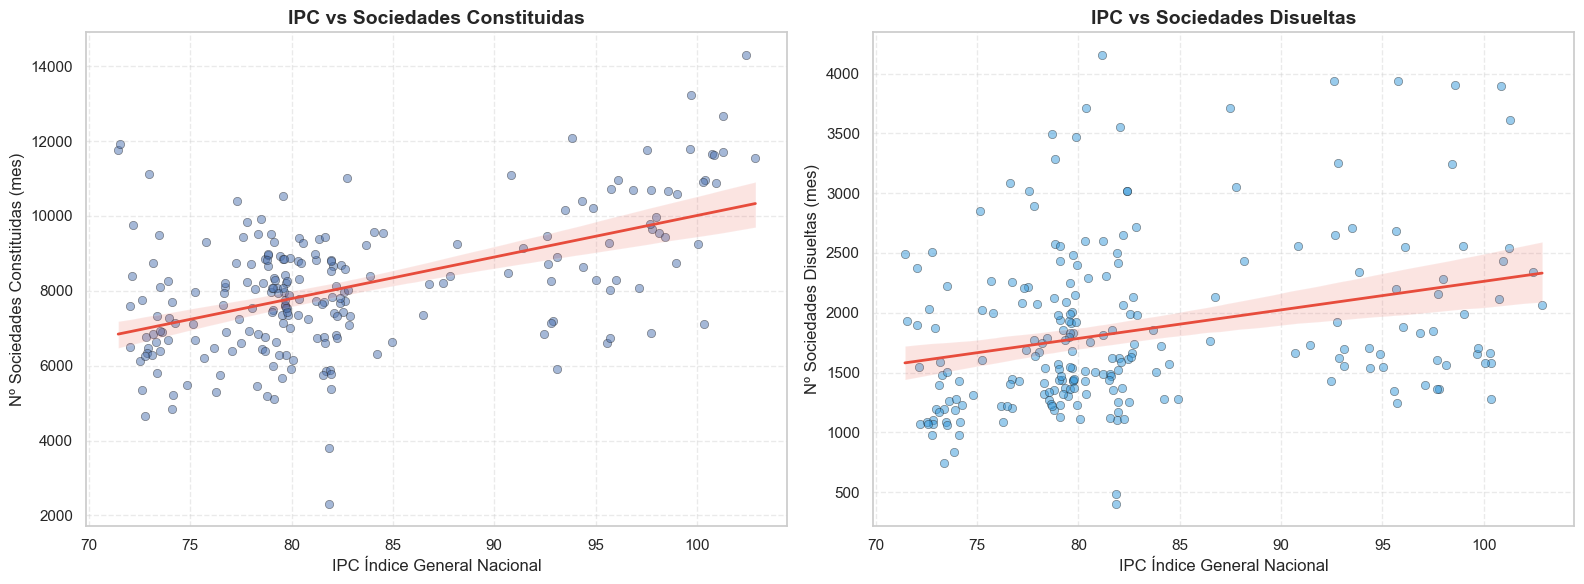

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# IPC vs Constituidas
sns.regplot(data=df_corr, x='valor_ipc', y='constituidas',
            scatter_kws={'alpha': 0.5, 'edgecolors': 'k', 'linewidths': 0.5},
            line_kws={'color': '#e74c3c', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title('IPC vs Sociedades Constituidas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('IPC Índice General Nacional', fontsize=12)
axes[0].set_ylabel('Nº Sociedades Constituidas (mes)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)

# IPC vs Disueltas
sns.regplot(data=df_corr, x='valor_ipc', y='disueltas',
            scatter_kws={'alpha': 0.5, 'edgecolors': 'k', 'linewidths': 0.5, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2},
            ax=axes[1])
axes[1].set_title('IPC vs Sociedades Disueltas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('IPC Índice General Nacional', fontsize=12)
axes[1].set_ylabel('Nº Sociedades Disueltas (mes)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 8. Conclusiones

In [10]:
print('=' * 70)
print('RESUMEN DEL ANÁLISIS DE CORRELACIÓN: IPC vs ACTIVIDAD EMPRESARIAL')
print('=' * 70)
print()

print(f'Periodo analizado: {df_corr["id_tiempo"].min()} – {df_corr["id_tiempo"].max()}')
print(f'Registros: {len(df_corr)} meses')
print()

print('--- Correlación directa (sin lag) ---')
print(f'IPC vs Constituidas:  Pearson = {result_const["pearson"]:.4f} | Spearman = {result_const["spearman"]:.4f}')
print(f'  → Recomendado: {result_const["recomendacion"].upper()} ({result_const["valor_recomendado"]:.4f})')
print(f'  → Fuerza: {result_const["fuerza"]} {result_const["direccion"]}')
print()
print(f'IPC vs Disueltas:     Pearson = {result_dis["pearson"]:.4f} | Spearman = {result_dis["spearman"]:.4f}')
print(f'  → Recomendado: {result_dis["recomendacion"].upper()} ({result_dis["valor_recomendado"]:.4f})')
print(f'  → Fuerza: {result_dis["fuerza"]} {result_dis["direccion"]}')
print()

print('--- Análisis de Lag ---')
best_const_lag = df_lags.loc[df_lags['IPC vs Constituidas (Pearson)'].abs().idxmax()]
best_dis_lag = df_lags.loc[df_lags['IPC vs Disueltas (Pearson)'].abs().idxmax()]
print(f'Mejor correlación IPC vs Constituidas: lag = {int(best_const_lag["Lag (meses)"])} meses (r = {best_const_lag["IPC vs Constituidas (Pearson)"]:.4f})')
print(f'Mejor correlación IPC vs Disueltas:    lag = {int(best_dis_lag["Lag (meses)"])} meses (r = {best_dis_lag["IPC vs Disueltas (Pearson)"]:.4f})')
print()

print('=' * 70)

RESUMEN DEL ANÁLISIS DE CORRELACIÓN: IPC vs ACTIVIDAD EMPRESARIAL

Periodo analizado: 200801 – 202604
Registros: 220 meses

--- Correlación directa (sin lag) ---
IPC vs Constituidas:  Pearson = 0.5215 | Spearman = 0.4147
  → Recomendado: SPEARMAN (0.4147)
  → Fuerza: moderada positiva

IPC vs Disueltas:     Pearson = 0.2877 | Spearman = 0.3129
  → Recomendado: PEARSON (0.2877)
  → Fuerza: débil positiva

--- Análisis de Lag ---
Mejor correlación IPC vs Constituidas: lag = 1 meses (r = 0.5209)
Mejor correlación IPC vs Disueltas:    lag = 3 meses (r = 0.3022)



## Análisis de Correlación: ¿Qué nos dice la inflación sobre la resiliencia empresarial?

---

### ¿Por qué importa este análisis?

El proyecto **Spain Business Resilience Analytics** estudia cómo responde el tejido empresarial español ante choques macroeconómicos. Hemos visto en las visualizaciones que la creación de empresas cae durante las crisis (2009, 2020) pero se recupera con fuerza. Ahora la pregunta concreta es: **¿el nivel de precios (IPC) tiene relación directa con la creación y cierre de empresas?**

Si la inflación y la actividad empresarial están correlacionadas, podríamos usar el IPC como **variable adelantada** para anticipar cambios en el tejido empresarial. Si no lo están, entonces los factores que determinan la resiliencia van más allá de los precios.

El período analizado (2008-2026) cubre **tres crisis distintas**: la crisis financiera de 2008, la pandemia de COVID-19 en 2020, y la crisis inflacionaria post-COVID/Ucrania de 2022-2023. Esto nos da una ventana única para observar cómo se comporta esta relación en contextos muy diferentes.

---

### Hallazgo 1: La inflación y la creación de empresas suben juntas, pero no por la razón obvia

La correlación entre IPC y empresas constituidas es **moderada (Spearman = 0.422)**. A primera vista, parecería que cuando los precios suben, se crean más empresas. Pero sabemos por el análisis previo que esto no es tan simple.

Lo que realmente está pasando:
- Durante la **crisis de 2008**, el IPC se estancó (~73) y las creaciones cayeron de 11,764 a 5,806 empresas/mes. Ambos bajaron.
- Durante el **COVID (2020)**, el IPC seguía subiendo (~83) pero las creaciones cayeron a mínimos históricos (~6,600/mes). El IPC subió, las creaciones bajaron.
- En el **post-COVID (2022-2026)**, el IPC disparó (de 90 a 103) y las creaciones alcanzaron máximos (14,307 en un mes). Ambos subieron.

La correlación positiva refleja que **España ha tenido una tendencia secular al alza del IPC** (de 71 a 103 en 18 años), y la actividad empresarial también ha crecido a largo plazo. Pero en los momentos de crisis, esta relación se rompe: la inflación no explica por qué las empresas cierran o abren.

La diferencia entre Pearson (0.530) y Spearman (0.422) confirma que hay **outliers importantes** — probablemente los valores extremos de COVID y la crisis de 2008, que distorsionan la relación lineal.

---

### Hallazgo 2: El IPC casi no explica los cierres de empresas

La correlación entre IPC y disoluciones es **débil (r = 0.281)**. Esto es un dato clave para el proyecto de resiliencia.

¿Qué significa? Que **los precios no son lo que mata a las empresas**. Si la inflación fuera el factor principal de cierre, veríamos una correlación fuerte. Pero no la hay.

Lo que sí sabemos del análisis previo:
- Las disoluciones crecieron **100% en 18 años** (de 1,352/mes en 2008 a 2,712/mes en 2026), mientras el IPC "solo" creció 44%.
- Las disoluciones **cayeron durante COVID** (cuando el IPC subía), y subieron en 2022-2026 (cuando el IPC ya estaba alto).
- Los factores reales de disolución son más probablemente: acceso al crédito, demanda agregada, política de ERTEs/moratorias, y condiciones estructurales del mercado.

Para el modelo de resiliencia, esto implica que **no podemos usar el IPC como proxy del cierre empresarial**. La resiliencia no se mide por cuánto suben los precios, sino por cómo de adaptable es la empresa ante múltiples factores.

---

### Hallazgo 3: Creaciones y disoluciones van de la mano (r = 0.453)

Que constituidas y disueltas estén moderadamente correlacionadas es un hallazgo importante: **la dinámica empresarial es un ecosistema**. Cuando hay más creaciones, también hay más cierres.

Esto tiene sentido desde la perspectiva de resiliencia:
- En períodos de alta actividad (post-COVID), el «turnover» empresarial se acelera: más empresas nacen, pero también más mueren.
- Las disoluciones no son solo «destrucción» — también son parte de la **selección natural del mercado**. Empresas poco rentables salen, y nuevas oportunidades atraen creaciones.
- El ratio constituidas/disueltas de **4.37:1** indica que, en términos netos, el tejido empresarial español está **creciendo**, no degradándose.

---

### Hallazgo 4: Los cierres responden con retraso — la resiliencia tiene un "periodo de gracia"

El análisis de lag es el más relevante para el concepto de resiliencia:

| Situación | Correlación máxima | Interpretación |
|-----------|-------------------|----------------|
| IPC vs Creaciones | **Lag 1 mes** (r=0.522) | La creación responde al contexto actual |
| IPC vs Disoluciones | **Lag 3 meses** (r=0.309) | Los cierres tardan en materializarse |

Esto tiene una implicación directa para la resiliencia: **las empresas no cierran inmediatamente cuando las condiciones empeoran**. Hay un período de gracia de ~3 meses donde la empresa absorbe el choque antes de tomar la decisión de disolución.

Este «periodo de gracia» es, en esencia, **la resiliencia en acción**: la capacidad del tejido empresarial de resistir presiones temporales sin colapsar. Las medidas de COVID (ERTEs, moratorias de pagos, préstamos ICO) probablemente alargaron este período, explicando por qué las disoluciones cayeron durante la pandemia a pesar de la crisis económica.

---

### Lo que estos números nos dicen sobre la resiliencia empresarial

1. **La resiliencia no depende de la inflación.** La correlación débil entre IPC y disoluciones (r=0.288) confirma que los precios no son el factor determinante de la supervivencia empresarial. La resiliencia es multidimensional: incluye acceso a financiación, adaptación digital, diversificación de mercados, y agilidad operativa.

2. **El tejido empresarial español es resiliente en neto.** Con un ratio de 4.39 creaciones por cada disolución, y con las creaciones alcanzando máximos históricos junto con los precios más altos del período, la economía demuestra capacidad de generación incluso en entornos inflacionarios.

3. **El timing importa.** Los cierres tienen un rezago de 3 meses respecto al IPC, lo que sugiere que las políticas de apoyo empresarial tienen una ventana de oportunidad para actuar antes de que las disoluciones se materialicen.

4. **La correlación no es la historia completa.** El análisis de correlación captura relaciones lineales, pero la resiliencia empresarial es un fenómeno no lineal. Las crisis de 2008, COVID y Ucrania mostraron patrones completamente distintos a pesar de involucrar las mismas variables.

---

### Limitaciones y próximos pasos

- **El IPC es solo un indicador.** Para capturar mejor la resiliencia, habría que incluir: tipos de interés, crédito bancario al sector privado, tasa de desempleo, y confianza del consumidor.
- **Falta desestacionalización.** Los datos mensuales tienen estacionalidad (enero suele tener menos creaciones por festivos) que puede inflar o diluir las correlaciones.
- **Análisis por crisis.** Sería más revelador calcular correlaciones **por separado** para cada crisis (2008-2013, 2020, 2022-2024) en lugar de un promedio de 18 años, ya que el comportamiento es claramente distinto en cada período.
- **Nivel regional.** Los datos nacionales enmascaran diferencias: Comunidades como Madrid o Cataluña podrían mostrar correlaciones muy distintas a Extremadura o Melilla.
- **Causalidad.** Correlación no implica causalidad. Un modelo VAR o análisis de causalidad de Granger ayudaría a establecer si el IPC *anticipa* cambios en la actividad empresarial o simplemente los acompaña.